# Steam Game Reviews
## Notebook 04 — Fine-tuned DistilBERT classifier and SHAP explainability

Owner: Mitsos · local (Apple Silicon)

The deep-learning half of Task 1: fine-tuning a pretrained transformer on the
recommendation label and explaining it with SHAP. The frozen-representation
baselines come from notebook 03.

Steps:
1. Setup, data and splits
2. Tokenisation and loaders
3. Fine-tuning with class-weighted loss
4. Evaluation on held-out games
5. Traditional vs deep learning comparison
6. Error analysis
7. SHAP explanations
8. Save

Design decisions. We fine-tune `distilbert-base-uncased` rather than train from
scratch: ~87k reviews is enough to adapt a pretrained model but far short of what
training a transformer requires. The label is roughly 80/20, so the loss is
class-weighted rather than resampled, which keeps all the data. Split indices come
from notebook 00 and are grouped by game. Input is `model_text`, which has the
leading-year artifact removed.

**Runtime.** Roughly 45-70 minutes for training on an M4 Pro, plus 10-25 minutes for
SHAP. MPS trains in fp32 — mixed precision is unstable on Metal, so there is no fp16
speedup as there would be on CUDA.


## 1. Setup, data and splits

In [1]:
from pathlib import Path
import gc
import json
import os
import random
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import display
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import GroupShuffleSplit

warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["HF_HUB_DISABLE_XET"] = "1"

# Fix all random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

def find_project_dir(markers=("Data", "data", "outputs"), max_up=4):
    """Locate the project root by walking up from the working directory.

    Portable across macOS, Windows and Linux: no hard-coded absolute paths, and it
    works whether the notebook sits in the project root or in a subfolder.
    """
    start = Path.cwd().resolve()
    for candidate in [start, *start.parents][: max_up + 1]:
        if any((candidate / marker).exists() for marker in markers):
            return candidate
    raise FileNotFoundError(
        f"Could not locate the project root starting from {start}.\n"
        f"Expected a folder containing one of {markers}.\n"
        "Open the notebook from inside the project folder (the one holding Data/)."
    )

PROJECT_DIR = find_project_dir()

OUTPUT_DIR = PROJECT_DIR / "outputs"
DATA_PATH = OUTPUT_DIR / "embeddings" / "sbert_row_metadata.csv"
SPLIT_DIR = OUTPUT_DIR / "splits"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
MODEL_DIR = OUTPUT_DIR / "models" / "distilbert_sentiment"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

assert DATA_PATH.exists(), f"Run notebook 03 first — missing {DATA_PATH}"

# CUDA (Windows/Linux + NVIDIA) -> MPS (Apple Silicon) -> CPU.
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

# Load the row-aligned metadata written by notebook 03, plus the split indices from notebook 00
df = pd.read_csv(DATA_PATH, low_memory=False)
train_idx_all = np.load(SPLIT_DIR / "train_idx.npy")
test_idx = np.load(SPLIT_DIR / "test_idx.npy")

# Carve a validation set out of the training pool, again grouped by game, so no
# game appears in more than one of fit / validation / test.
train_pool = df.loc[train_idx_all].copy()
validation_splitter = GroupShuffleSplit(n_splits=1, test_size=0.10, random_state=SEED)
fit_local, val_local = next(validation_splitter.split(
    train_pool, train_pool["target"], groups=train_pool["game_name"]))
fit_idx = train_pool.index.to_numpy()[fit_local]
val_idx = train_pool.index.to_numpy()[val_local]

# Sanity check: no game may appear in more than one of fit / validation / test
fit_games = set(df.loc[fit_idx, "game_name"])
val_games = set(df.loc[val_idx, "game_name"])
test_games = set(df.loc[test_idx, "game_name"])
assert not (fit_games & val_games) and not (fit_games & test_games) and not (val_games & test_games)

print("Device:", DEVICE)
print("Fit / validation / test reviews:",
      f"{len(fit_idx):,}", f"{len(val_idx):,}", f"{len(test_idx):,}")
print("Fit / validation / test games:", len(fit_games), len(val_games), len(test_games))
print("Recommended share — fit / val / test:",
      f"{df.loc[fit_idx, 'target'].mean():.1%}",
      f"{df.loc[val_idx, 'target'].mean():.1%}",
      f"{df.loc[test_idx, 'target'].mean():.1%}")

Device: mps
Fit / validation / test reviews: 86,739 8,919 24,342
Fit / validation / test games: 173 20 49
Recommended share — fit / val / test: 79.3% 78.1% 81.3%


## 2. Tokenisation and loaders

DistilBERT's WordPiece tokenizer handles casing, punctuation and digits itself, so
`model_text` goes in essentially as written.


In [2]:
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer

# Training hyperparameters
MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 256        # covers well past the 90th percentile of review length
BATCH_SIZE = 32          # raise to 64 if memory pressure stays low
EPOCHS = 2              # validation score is checked after each one
LEARNING_RATE = 2e-5    # small, as usual when fine-tuning rather than training from scratch

# Load the matching WordPiece tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Minimal Dataset: hands back the raw text and its label, tokenisation happens per batch
class ReviewDataset(Dataset):
    def __init__(self, frame):
        self.texts = frame["model_text"].fillna("").astype(str).tolist()
        self.labels = frame["target"].astype(int).tolist()
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, index):
        return self.texts[index], self.labels[index]

# Tokenise one batch at a time and stack it into tensors
def collate_reviews(batch):
    texts, labels = zip(*batch)
    # Pad to the longest item in the batch rather than a fixed width: fewer wasted
    # tokens per step, which matters over ~5.4k steps per epoch.
    encoded = tokenizer(list(texts), padding=True, truncation=True,
                        max_length=MAX_LENGTH, return_tensors="pt")
    encoded["labels"] = torch.tensor(labels, dtype=torch.long)
    return encoded

# Loaders for the three splits; shuffle only the fitting set
fit_loader = DataLoader(ReviewDataset(df.loc[fit_idx]), batch_size=BATCH_SIZE,
                        shuffle=True, collate_fn=collate_reviews, num_workers=0)
val_loader = DataLoader(ReviewDataset(df.loc[val_idx]), batch_size=BATCH_SIZE * 2,
                        shuffle=False, collate_fn=collate_reviews, num_workers=0)
test_loader = DataLoader(ReviewDataset(df.loc[test_idx]), batch_size=BATCH_SIZE * 2,
                         shuffle=False, collate_fn=collate_reviews, num_workers=0)

print("Batches — fit / validation / test:",
      len(fit_loader), len(val_loader), len(test_loader))
print("Optimizer steps planned:", f"{EPOCHS * len(fit_loader):,}")

Batches — fit / validation / test: 2711 140 381
Optimizer steps planned: 5,422


## 3. Fine-tuning

A plain PyTorch loop rather than `Trainer`, so the class-weighted loss and the
per-step logging stay explicit. Weights are inverse class frequencies computed on
the fitting split only. Validation macro-F1 is checked at the end of each epoch and
the better checkpoint is kept.

If a completed model is already saved, the notebook reuses it instead of retraining.


In [3]:
from transformers import AutoModelForSequenceClassification, get_linear_schedule_with_warmup

# Run the model over a loader and return true labels, predictions and positive-class probabilities
def evaluate_loader(model, data_loader):
    model.eval()
    labels_all, predictions, probabilities = [], [], []
    with torch.no_grad():
        for batch in data_loader:
            labels = batch.pop("labels")
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            logits = model(**batch).logits
            probs = torch.softmax(logits.float(), dim=-1).cpu().numpy()
            predictions.extend(probs.argmax(axis=1).tolist())
            probabilities.extend(probs[:, 1].tolist())
            labels_all.extend(labels.numpy().tolist())
    return np.array(labels_all), np.array(predictions), np.array(probabilities)

# Compute inverse-frequency class weights on the fitting split only
fit_labels = df.loc[fit_idx, "target"].astype(int).to_numpy()
class_counts = np.bincount(fit_labels, minlength=2)
class_weights = len(fit_labels) / (2 * class_counts)
print("Class counts:", class_counts, "-> weights:", class_weights.round(3))

# Skip training entirely if a finished model is already on disk
reuse_saved = (MODEL_DIR / "model.safetensors").exists() and (MODEL_DIR / "test_metrics.json").exists()

if reuse_saved:
    print("Reusing the saved fine-tuned model; training skipped.")
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR).to(DEVICE)
    with open(MODEL_DIR / "test_metrics.json") as handle:
        training_seconds = json.load(handle)["training_seconds"]
else:
    # Load the pretrained encoder with a fresh 2-class head
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2).to(DEVICE)
    # Cross-entropy weighted by inverse class frequency, so the minority class is not ignored
    loss_function = torch.nn.CrossEntropyLoss(
        weight=torch.tensor(class_weights, dtype=torch.float32, device=DEVICE))
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
    total_steps = EPOCHS * len(fit_loader)
    # Warm up for the first 6% of steps, then decay the learning rate linearly
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=int(0.06 * total_steps), num_training_steps=total_steps)

    training_rows, best_macro_f1, step = [], -1.0, 0
    start_time = time.time()
    # Training loop
    for epoch in range(1, EPOCHS + 1):
        model.train()
        running_loss = 0.0
        for batch in fit_loader:
            step += 1
            labels = batch.pop("labels").to(DEVICE)
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            optimizer.zero_grad(set_to_none=True)
            loss = loss_function(model(**batch).logits, labels)
            loss.backward()
            # Clip gradients to stop occasional large updates destabilising training
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            running_loss += loss.item()
            if step % 250 == 0:
                elapsed = time.time() - start_time
                mean_loss = running_loss / 250
                training_rows.append({"epoch": epoch, "step": step, "loss": mean_loss,
                                      "elapsed_seconds": elapsed})
                print(f"epoch {epoch} | step {step:,}/{total_steps:,} | "
                      f"loss {mean_loss:.4f} | {elapsed/60:.1f} min")
                running_loss = 0.0

        # Evaluate on validation at the end of each epoch and keep the better checkpoint
        v_true, v_pred, _ = evaluate_loader(model, val_loader)
        v_macro = f1_score(v_true, v_pred, average="macro")
        print(f"--- epoch {epoch} validation macro-F1: {v_macro:.4f}")
        if v_macro > best_macro_f1:
            best_macro_f1 = v_macro
            model.save_pretrained(MODEL_DIR)
            tokenizer.save_pretrained(MODEL_DIR)
            print("    checkpoint saved (best so far)")

    training_seconds = time.time() - start_time
    pd.DataFrame(training_rows).to_csv(TABLE_DIR / "distilbert_training_log.csv", index=False)
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR).to(DEVICE)
    print("Best validation macro-F1:", round(best_macro_f1, 4))

print("Training time (minutes):", round(training_seconds / 60, 1))

Class counts: [17927 68812] -> weights: [2.419 0.63 ]
Reusing the saved fine-tuned model; training skipped.


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 8063.88it/s]


Training time (minutes): 51.6


## 4. Evaluation on held-out games

In [4]:
# Evaluate the final model on validation and on the held-out games
val_true, val_pred, _ = evaluate_loader(model, val_loader)
test_true, test_pred, test_probability = evaluate_loader(model, test_loader)

metrics = {
    "validation_accuracy": accuracy_score(val_true, val_pred),
    "validation_macro_f1": f1_score(val_true, val_pred, average="macro"),
    "test_accuracy": accuracy_score(test_true, test_pred),
    "test_macro_f1": f1_score(test_true, test_pred, average="macro"),
    "test_negative_f1": f1_score(test_true, test_pred, pos_label=0),
    "training_seconds": training_seconds,
    "epochs": EPOCHS,
    "max_length": MAX_LENGTH,
    "batch_size": BATCH_SIZE,
    "fit_reviews": int(len(fit_idx)),
    "validation_reviews": int(len(val_idx)),
    "test_reviews": int(len(test_idx)),
}
# Save the metrics next to the model so downstream runs can reuse them
with open(MODEL_DIR / "test_metrics.json", "w") as handle:
    json.dump(metrics, handle, indent=2)

print(json.dumps({k: (round(v, 4) if isinstance(v, float) else v) for k, v in metrics.items()}, indent=2))
print(classification_report(test_true, test_pred,
                            target_names=["Not Recommended", "Recommended"]))

{
  "validation_accuracy": 0.9267,
  "validation_macro_f1": 0.8956,
  "test_accuracy": 0.9292,
  "test_macro_f1": 0.8871,
  "test_negative_f1": 0.8182,
  "training_seconds": 3094.681,
  "epochs": 2,
  "max_length": 256,
  "batch_size": 32,
  "fit_reviews": 86739,
  "validation_reviews": 8919,
  "test_reviews": 24342
}
                 precision    recall  f1-score   support

Not Recommended       0.79      0.85      0.82      4546
    Recommended       0.97      0.95      0.96     19796

       accuracy                           0.93     24342
      macro avg       0.88      0.90      0.89     24342
   weighted avg       0.93      0.93      0.93     24342



## 5. Traditional vs deep learning

The frozen-representation numbers come from notebook 03 and were computed on the
same group-aware test split, so the comparison is like for like: identical 24,342
reviews from 49 unseen games.


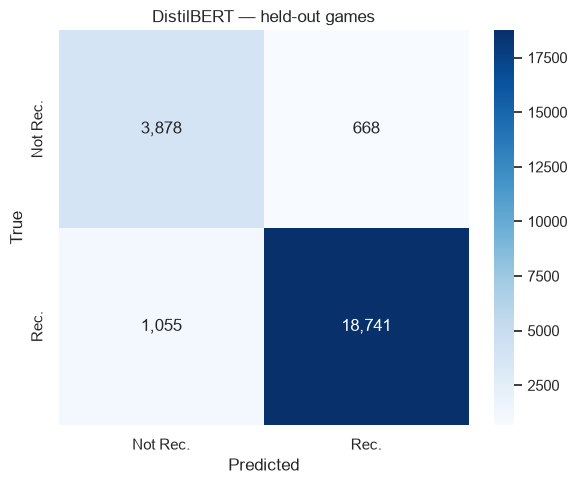

,representation,accuracy,macro_f1,negative_f1
0,"TF-IDF (1-2 grams, 50k features)",0.893,0.836,0.739
1,Word2Vec mean (100d),0.851,0.789,0.673
2,Sentence-BERT (384d),0.850,0.786,0.670
3,DistilBERT fine-tuned,0.929,0.887,0.818


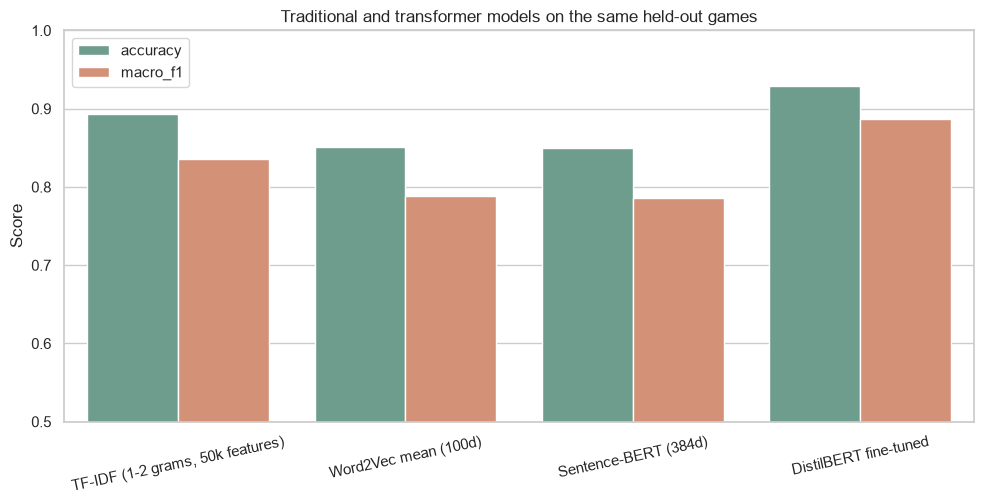

In [5]:
# Confusion matrix on the held-out games
cm = confusion_matrix(test_true, test_pred)
sns.set_theme(style="white", context="notebook")
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt=",", cmap="Blues", cbar=True,
            xticklabels=["Not Rec.", "Rec."], yticklabels=["Not Rec.", "Rec."], ax=ax)
ax.set(title="DistilBERT — held-out games", xlabel="Predicted", ylabel="True")
fig.tight_layout(); fig.savefig(FIGURE_DIR / "distilbert_confusion_matrix.png", dpi=180, bbox_inches="tight"); plt.show()

# Append the DistilBERT row to notebook 03's comparison table
baseline = pd.read_csv(TABLE_DIR / "embedding_comparison.csv")
comparison = baseline[["representation", "accuracy", "macro_f1", "negative_f1"]].copy()
comparison = pd.concat([comparison, pd.DataFrame([{
    "representation": "DistilBERT fine-tuned",
    "accuracy": metrics["test_accuracy"],
    "macro_f1": metrics["test_macro_f1"],
    "negative_f1": metrics["test_negative_f1"],
}])], ignore_index=True)
comparison.to_csv(TABLE_DIR / "task1_model_comparison.csv", index=False)
display(comparison.style.format({"accuracy": "{:.3f}", "macro_f1": "{:.3f}", "negative_f1": "{:.3f}"}))

# Bar chart of all four models on the same test set
sns.set_theme(style="whitegrid", context="notebook")
plot_data = comparison.melt(id_vars="representation", value_vars=["accuracy", "macro_f1"],
                            var_name="metric", value_name="score")
fig, ax = plt.subplots(figsize=(10, 5.2))
sns.barplot(data=plot_data, x="representation", y="score", hue="metric",
            palette=["#67A58F", "#E28C69"], ax=ax)
ax.set(title="Traditional and transformer models on the same held-out games",
       xlabel="", ylabel="Score", ylim=(0.5, 1.0))
ax.tick_params(axis="x", rotation=12); ax.legend(title="")
fig.tight_layout(); fig.savefig(FIGURE_DIR / "task1_model_comparison.png", dpi=180, bbox_inches="tight"); plt.show()

## 6. Error analysis

Inspecting the most confident misclassifications, which is more informative than the
aggregate error rate. The usual sources are sarcasm, mixed verdicts ("great story,
terrible port") and joke reviews.


In [6]:
# Attach predictions and probabilities to the test rows
test_view = df.loc[test_idx, ["game_name", "recommendation", "model_text"]].copy().reset_index(drop=True)
test_view["true"] = test_true
test_view["predicted"] = test_pred
test_view["recommended_probability"] = test_probability
# Keep only the misclassified reviews and label which direction the error went
errors = test_view.loc[test_view["true"].ne(test_view["predicted"])].copy()
errors["error_type"] = np.where(errors["true"].eq(0), "false_positive", "false_negative")
errors.to_csv(TABLE_DIR / "distilbert_errors.csv", index=False)

print("Errors:", f"{len(errors):,}", f"({len(errors)/len(test_view):.1%})")
# Sort by confidence to surface the cases the model was most sure about
print("\nMost confident false positives (predicted Recommended, actually not):")
display(errors[errors.error_type.eq("false_positive")]
        .sort_values("recommended_probability", ascending=False).head(6))
print("Most confident false negatives:")
display(errors[errors.error_type.eq("false_negative")]
        .sort_values("recommended_probability").head(6))

Errors: 1,723 (7.1%)

Most confident false positives (predicted Recommended, actually not):


,game_name,recommendation,model_text,true,predicted,recommended_probability,error_type
1640,Call of Duty®: Black Ops III,Not Recommended,"Its my favorite game of all time, totally reco...",0,1,0.998574,false_positive
844,Call of Duty®,Not Recommended,"Oh, what a delightful experience it was to be ...",0,1,0.998573,false_positive
6461,Little Nightmares II,Not Recommended,WHY YOU LOOKING THROUGH THE NEGATIVE REVIEWS? ...,0,1,0.997430,false_positive
20484,MARVEL SNAP,Not Recommended,Early Access Review it's ok,0,1,0.997260,false_positive
18029,Aimlabs,Not Recommended,Early Access Review good game :3,0,1,0.997180,false_positive
7005,Chained Together,Not Recommended,i don't think i would recommend this game to a...,0,1,0.996990,false_positive


Most confident false negatives:


,game_name,recommendation,model_text,true,predicted,recommended_probability,error_type
12919,Yu-Gi-Oh! Master Duel,Recommended,"uninstall, can't enjoy fighting anymore. becau...",1,0,0.003728,false_negative
23060,Liftoff®: FPV Drone Racing,Recommended,so firtst off when i purchased this game i did...,1,0,0.004371,false_negative
22409,WWE 2K24,Recommended,It's 2K23 with a bunch of half baked gimmick m...,1,0,0.004452,false_negative
18045,Total War: THREE KINGDOMS,Recommended,This game is abandoned and incomplete.They hav...,1,0,0.004475,false_negative
20449,MARVEL SNAP,Recommended,Early Access Review ♥♥♥♥♥♥♥♥♥ how did this tut...,1,0,0.004570,false_negative
21278,Northgard,Recommended,I really want to love this game. The art style...,1,0,0.004571,false_negative


## 7. SHAP explanations

SHAP attributes each prediction to individual tokens. We compute a global view — the
tokens with the highest mean absolute SHAP value across 50 held-out reviews, which
satisfies the XAI requirement on a global basis — plus two local force plots.

Sample size matters: an earlier run explained only a handful of reviews and the
ranking was dominated by whatever words happened to appear in them.

This section is also where a data problem surfaced. The first global ranking put year
tokens among the top predictors, which traced back to a scraping artifact — the
review's year had been concatenated onto the front of its text. It is corrected
upstream in notebook 00, and the ranking below is from the retrained model.


In [7]:
import shap
from transformers import pipeline

SHAP_SAMPLE_SIZE = 50

# SHAP's partition explainer is more stable off MPS, so move the model to CPU first
model.to("cpu")            # SHAP's partition explainer is more stable off MPS
gc.collect()
if torch.backends.mps.is_available():
    torch.mps.empty_cache()

# Wrap the model in a pipeline, which is the interface SHAP expects
classifier = pipeline("text-classification", model=model, tokenizer=tokenizer,
                      top_k=None, device=-1)
explainer = shap.Explainer(classifier)

# Explain 50 short-to-medium reviews: long ones are slow and dominated by padding
short_test = df.loc[test_idx].loc[df.loc[test_idx, "word_count"].between(8, 60)]
shap_sample = short_test.sample(n=min(SHAP_SAMPLE_SIZE, len(short_test)), random_state=SEED)
print("Explaining", len(shap_sample), "reviews — this takes several minutes...")
shap_values = explainer(shap_sample["model_text"].tolist())
print("Done.")

Explaining 50 reviews — this takes several minutes...


PartitionExplainer explainer: 51it [05:35,  6.71s/it]                        

Done.


,token,absolute_shap,occurrences
0,amazing,0.202888,4
1,great,0.178803,4
2,best,0.173571,5
3,fun,0.121931,12
4,recommend,0.111849,5
5,no,0.062178,5
6,love,0.057353,6
7,10,0.057172,11
8,because,0.050098,3
9,(,0.044001,3


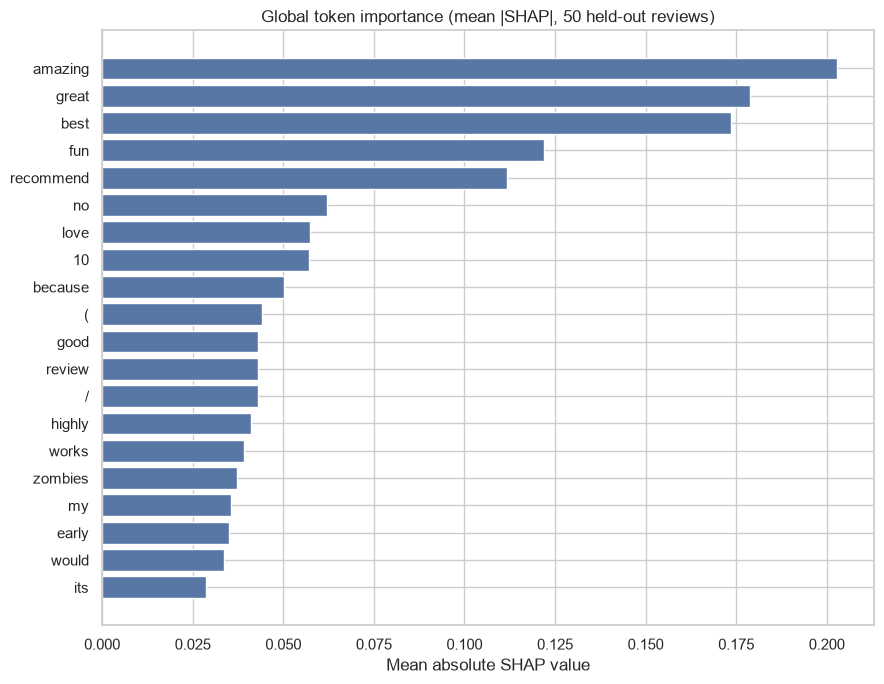

In [8]:
# Flatten the per-review token attributions into one long table
token_rows = []
values = shap_values.values
for review_number in range(len(shap_sample)):
    tokens = shap_values.data[review_number]
    review_array = np.asarray(values[review_number])
    review_values = (review_array[:, 1] if review_array.ndim == 2 and review_array.shape[-1] == 2
                     else review_array.reshape(-1))
    for token, contribution in zip(tokens, review_values):
        # Strip WordPiece continuation marks and drop the special tokens
        clean_token = str(token).replace("##", "").strip().lower()
        if clean_token and clean_token not in {"[cls]", "[sep]", "[pad]"}:
            token_rows.append({"token": clean_token, "absolute_shap": abs(float(contribution))})

# Average each token's absolute contribution across all the reviews it appears in
token_frame = pd.DataFrame(token_rows)
# Require a token to appear a few times before trusting its mean contribution.
counts = token_frame.groupby("token")["absolute_shap"].agg(["mean", "size"])
global_tokens = (counts.loc[counts["size"] >= 3]
                 .sort_values("mean", ascending=False).head(25)
                 .rename(columns={"mean": "absolute_shap", "size": "occurrences"})
                 .reset_index())
global_tokens.to_csv(TABLE_DIR / "shap_global_tokens.csv", index=False)
display(global_tokens)

# Horizontal bar chart of the 20 most influential tokens
fig, ax = plt.subplots(figsize=(9, 7))
plot_tokens = global_tokens.head(20).sort_values("absolute_shap")
ax.barh(plot_tokens["token"], plot_tokens["absolute_shap"], color="#5877A5")
ax.set(title=f"Global token importance (mean |SHAP|, {len(shap_sample)} held-out reviews)",
       xlabel="Mean absolute SHAP value", ylabel="")
fig.tight_layout(); fig.savefig(FIGURE_DIR / "shap_global_tokens.png", dpi=180, bbox_inches="tight"); plt.show()

In [9]:
# Local explanations: one review from each class.
# Pick one review from each class and show a local force plot for it
sample_reset = shap_sample.reset_index(drop=True)
neg_positions = sample_reset.index[sample_reset["target"].eq(0)]
pos_positions = sample_reset.index[sample_reset["target"].eq(1)]

if len(neg_positions):
    i = int(neg_positions[0])
    print("NEGATIVE example:", sample_reset.loc[i, "model_text"][:200])
    shap.plots.text(shap_values[i, :, 1])

if len(pos_positions):
    i = int(pos_positions[0])
    print("POSITIVE example:", sample_reset.loc[i, "model_text"][:200])
    shap.plots.text(shap_values[i, :, 1])

NEGATIVE example: F**k this, go do anything else with your time,play a game that isn't owned by a garbage conglomerate.All they care about is more monetization monetization and guess what, monetization.CHEATERS? we don


POSITIVE example: Early Access Review Me and my friend went into a gas station, and he diedI drunk bleach.It started to rain.Spent my last moments enjoying the rain, getting chomped on by zombies5000000/10


## 8. Save

The fine-tuned model and tokenizer go to `outputs/models/distilbert_sentiment/`,
alongside the Task 1 comparison table, the training log, the misclassified reviews
and the global SHAP tokens under `outputs/tables/`. Results and their interpretation
are discussed in the report.

**Next:** notebook 05 — the RAG system.


In [10]:
# Store readable label names in the config, then save model and tokenizer together
model.config.id2label = {0: "Not Recommended", 1: "Recommended"}
model.config.label2id = {"Not Recommended": 0, "Recommended": 1}
model.save_pretrained(MODEL_DIR)
tokenizer.save_pretrained(MODEL_DIR)


# End-of-notebook checks: data, splits, metrics and saved artifacts are all consistent
assert len(df) == 120_000
assert not (fit_games & val_games) and not (fit_games & test_games) and not (val_games & test_games)
assert len(test_true) == len(test_idx)
assert 0 <= metrics["test_accuracy"] <= 1 and 0 <= metrics["test_macro_f1"] <= 1
assert (MODEL_DIR / "config.json").exists()
assert (TABLE_DIR / "shap_global_tokens.csv").exists()
print("Saved model to", MODEL_DIR)
print("All classifier, split and output checks passed.")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  6.50it/s]

Saved model to /Users/ioannis_tsantilas/Tsantil/Deree/MSc Data Science/ITC6110B1 - NATURAL LANGUAGE PROCESSING - SPRING TERM 2026/Group Project/outputs/models/distilbert_sentiment
All classifier, split and output checks passed.
